# **March Madness Game Winner Predictive Machine Learning Pipeline**


## Results, Findings, and Caveats

### What We Found

**SGDClassifier was the best model**, achieving 82.5% test accuracy compared to Logistic Regression at 80.2% and the seed baseline at 74.6%. This was not obvious at the outset — logistic regression is the standard choice for this type of problem and had higher cross-validation accuracy (80.3% vs 79.7%). SGD won on test accuracy despite lower CV accuracy, which the overlap analysis explained: SGD correctly predicted 5 games that LR missed while only losing 2 games that LR got right.

**The model performs differently across tournament types.** In 2024, an upset-heavy tournament, SGD achieved 85.7% accuracy compared to the seed baseline of 69.8% — a massive +15.9pp lift. In 2025, a chalk tournament where favorites won consistently, SGD achieved 79.4% accuracy while the seed baseline also hit 79.4% — essentially a tie. This pattern suggests the model's edge comes primarily from identifying upsets correctly, which is where pure seed-based prediction breaks down most severely.

**Symmetry augmentation was the single biggest improvement.** Before augmentation, CV accuracy sat at ~73%. After doubling the training data by mirroring every game with the outcome flipped and all difference features negated, CV accuracy jumped to ~80%. No other single change came close to this improvement.

**More hyperparameter tuning did not always help.** Expanding the search space to include learning rate schedules and per-model feature count ranges with 200-300 trials consistently performed worse than the simpler 3-parameter search with 50 trials. This is a direct consequence of dataset size — with 880 training rows, Optuna needs far more trials to cover a 6-parameter space reliably than a 3-parameter space, and the additional parameters introduced overfitting rather than improvement.

**The ensemble did not beat the best individual model.** A soft-voting ensemble of LR + SGD + Passive Aggressive scored 80.95% accuracy — below SGD's 82.5%. CV-optimized weighting assigned 90.6% weight to LR and only 9.4% to SGD, producing LR-level accuracy. This reveals that while SGD makes better binary predictions, LR produces better-calibrated probabilities — a distinction between accuracy and log loss that the weighting optimizer exposed.

**Cross-validation underestimates real performance.** The per-fold breakdown shows a clear pattern: early folds training on only 1-2 years of data score ~73-75%, while later folds training on 5-6 years score ~85-88%. The mean CV score is dragged down by data-starved early folds that don't represent real deployment conditions. By 2026, the model will train on 9 full years of data, putting it closer to fold 4-5 conditions than the overall CV mean suggests.

### Caveats

**The test set is small.** 126 games across two tournaments carries a 95% confidence interval of ±7.4 percentage points. The difference between 82.5% and 80.2% is only 3 games — well within the margin of uncertainty. Definitive conclusions about which model is truly better would require many more tournament years.

**2025 was an unusually chalk-heavy tournament.** The seed baseline hit 79.4% in 2025, its highest in the dataset. The model tying the seed baseline in 2025 is not necessarily a failure — it may simply reflect that 2025 had very few genuinely unpredictable games where the model's efficiency metrics could add value over seeds alone.

**The model cannot predict true upsets.** When all rating systems agree a team should lose, the model will predict a loss regardless of intangible factors — momentum, injuries, coaching adjustments, or the randomness inherent in single-elimination basketball. The ~17.5% of games the model gets wrong likely includes a large proportion of games that are genuinely unpredictable by any statistical approach.

**Results are sensitive to the random seed.** Changing `seed=27` to a different value produces meaningfully different results due to SGDClassifier's stochastic training process. The 82.5% result is reproducible with seed 27 but should not be interpreted as the definitive expected accuracy — it represents one point in a distribution of outcomes that likely ranges from approximately 78% to 85% depending on the seed.

**Public picks were deliberately excluded.** Several published models reporting 87%+ accuracy include public pick percentages as a feature, which aggregates the collective prediction of millions of users. Excluding this feature makes the methodology more defensible and interpretable, but it does impose an accuracy ceiling relative to models that use it.

#### Imports and dataset downloading from kaggle

In [ ]:
%pip install optuna
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, log_loss
from scipy.optimize import minimize
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np
import kagglehub
import warnings
import optuna
import random

# Download latest version
path = kagglehub.dataset_download("nishaanamin/march-madness-data")

print("Path to dataset files:", path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.0 MB/s eta 0:00:00


100%|██████████| 1.75M/1.75M [00:00<00:00, 165MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nishaanamin/march-madness-data/versions/146


#### **Dataset loading into pandas dataframes**

In [ ]:
# Load all CSV files into data frames
ratings538_df = pd.read_csv(f"{path}/538 Ratings.csv")
appoll_df = pd.read_csv(f"{path}/AP Poll Data.csv")
bart_away_neut_df = pd.read_csv(f"{path}/Barttorvik Away-Neutral.csv")
bart_away_df = pd.read_csv(f"{path}/Barttorvik Away.csv")
bart_home_df = pd.read_csv(f"{path}/Barttorvik Home.csv")
bart_neutral_df = pd.read_csv(f"{path}/Barttorvik Neutral.csv")
coach_results_df = pd.read_csv(f"{path}/Coach Results.csv")
conf_results_df = pd.read_csv(f"{path}/Conference Results.csv")
conf_stats_away_neut_df = pd.read_csv(f"{path}/Conference Stats Away Neutral.csv")
conf_stats_away_df = pd.read_csv(f"{path}/Conference Stats Away.csv")
conf_stats_home_df = pd.read_csv(f"{path}/Conference Stats Home.csv")
conf_stats_neut_df = pd.read_csv(f"{path}/Conference Stats Neutral.csv")
conf_stats_df = pd.read_csv(f"{path}/Conference Stats.csv")
evanmiya_df = pd.read_csv(f"{path}/EvanMiya.csv")
heatchk_df = pd.read_csv(f"{path}/Heat Check Ratings.csv")
heatchk_tourney_df = pd.read_csv(f"{path}/Heat Check Tournament Index.csv")
kenpom_bart_df = pd.read_csv(f"{path}/KenPom Barttorvik.csv")
kenpom_pre_df = pd.read_csv(f"{path}/KenPom Preseason.csv")
publicpicks_df = pd.read_csv(f"{path}/Public Picks.csv")
rppf_conf_df = pd.read_csv(f"{path}/RPPF Conference Ratings.csv")
rppf_pre_df = pd.read_csv(f"{path}/RPPF Preseason Ratings.csv")
rppf_df = pd.read_csv(f"{path}/RPPF Ratings.csv")
resumes_df = pd.read_csv(f"{path}/Resumes.csv")
seed_results_df = pd.read_csv(f"{path}/Seed Results.csv")
shooting_df = pd.read_csv(f"{path}/Shooting Splits.csv")
team_results_df = pd.read_csv(f"{path}/Team Results.csv")
tr_away_df = pd.read_csv(f"{path}/TeamRankings Away.csv")
tr_home_df = pd.read_csv(f"{path}/TeamRankings Home.csv")
tr_neutral_df = pd.read_csv(f"{path}/TeamRankings Neutral.csv")
teamrankings_df = pd.read_csv(f"{path}/TeamRankings.csv")
teamsheet_df = pd.read_csv(f"{path}/Teamsheet Ranks.csv")
locations_df = pd.read_csv(f"{path}/Tournament Locations.csv")
matchups_df = pd.read_csv(f"{path}/Tournament Matchups.csv")
simulation_df = pd.read_csv(f"{path}/Tournament Simulation.csv")
upset_count_df = pd.read_csv(f"{path}/Upset Count.csv")
upset_seed_df = pd.read_csv(f"{path}/Upset Seed Info.csv")
zratings_cum_df = pd.read_csv(f"{path}/Z Rating Cumulative.csv")
zratings_df = pd.read_csv(f"{path}/Z Rating Teams.csv")

# List for iteration and inspection
dataframes = [
    ("538 Ratings", ratings538_df), ("AP Poll", appoll_df), ("Bart Away-Neut", bart_away_neut_df),
    ("Bart Away", bart_away_df), ("Bart Home", bart_home_df), ("Bart Neutral", bart_neutral_df),
    ("Coach Results", coach_results_df), ("Conf Results", conf_results_df),
    ("Conf Stats Away Neut", conf_stats_away_neut_df), ("Conf Stats Away", conf_stats_away_df),
    ("Conf Stats Home", conf_stats_home_df), ("Conf Stats Neutral", conf_stats_neut_df),
    ("Conference Stats", conf_stats_df), ("EvanMiya", evanmiya_df), ("Heat Check", heatchk_df),
    ("Heat Check Tourney", heatchk_tourney_df), ("KenPom Bart", kenpom_bart_df),
    ("KenPom Preseason", kenpom_pre_df), ("Public Picks", publicpicks_df),
    ("RPPF Conf", rppf_conf_df), ("RPPF Preseason", rppf_pre_df), ("RPPF Ratings", rppf_df),
    ("Resumes", resumes_df), ("Seed Results", seed_results_df), ("Shooting Splits", shooting_df),
    ("Team Results", team_results_df), ("TR Away", tr_away_df), ("TR Home", tr_home_df),
    ("TR Neutral", tr_neutral_df), ("TeamRankings", teamrankings_df), ("Teamsheet", teamsheet_df),
    ("Locations", locations_df), ("Matchups", matchups_df), ("Simulation", simulation_df),
    ("Upset Count", upset_count_df), ("Upset Seed", upset_seed_df),
    ("Z Ratings Cum", zratings_cum_df), ("Z Ratings", zratings_df)
]

for name, df in dataframes:
    print(f"\n{name} — shape: {df.shape}")
    print(df.columns.tolist())
    print(df.head(2))


538 Ratings — shape: (544, 7)
['YEAR', 'TEAM NO', 'TEAM', 'SEED', 'ROUND', 'POWER RATING', 'POWER RATING RANK']
   YEAR  TEAM NO         TEAM  SEED  ROUND  POWER RATING  POWER RATING RANK
0  2024     1067  Connecticut     1      1          95.6                  4
1  2024     1056      Houston     1     16          94.9                  8

AP Poll — shape: (15372, 11)
['YEAR', 'WEEK', 'TEAM NO', 'TEAM', 'SEED', 'ROUND', 'W', 'L', 'AP VOTES', 'AP RANK', 'RANK?']
   YEAR  WEEK  TEAM NO     TEAM  SEED  ROUND    W    L  AP VOTES  AP RANK  \
0  2025     1   1123.0   Kansas   7.0   64.0  0.0  0.0    1449.0      1.0   
1  2025     1   1146.0  Alabama   2.0    8.0  0.0  0.0    1428.0      2.0   

   RANK?  
0      1  
1      1  

Bart Away-Neut — shape: (1147, 85)
['YEAR', 'TEAM NO', 'TEAM ID', 'TEAM', 'SEED', 'ROUND', 'BADJ EM', 'BADJ O', 'BADJ D', 'BARTHAG', 'GAMES', 'W', 'L', 'WIN%', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%', 'TOV%D', 'OREB%', 'DREB%', 'OP OREB%', 'OP DREB%', 'RAW T', '2PT%', 

#### **Merging useful datasets**
After much testing, I slimmed down what datasets were useful and which weren't.

In [ ]:
# 1. Load only the useful CSV files
matchups_df      = pd.read_csv(f"{path}/Tournament Matchups.csv")
kenpom_df        = pd.read_csv(f"{path}/KenPom Barttorvik.csv")
teamrankings_df  = pd.read_csv(f"{path}/TeamRankings.csv")
resumes_df       = pd.read_csv(f"{path}/Resumes.csv")
shooting_df      = pd.read_csv(f"{path}/Shooting Splits.csv")
evanmiya_df      = pd.read_csv(f"{path}/EvanMiya.csv")
rppf_df          = pd.read_csv(f"{path}/RPPF Ratings.csv")
heatchk_df       = pd.read_csv(f"{path}/Heat Check Ratings.csv")
bart_away_neut_df = pd.read_csv(f"{path}/Barttorvik Away-Neutral.csv")
bart_neutral_df  = pd.read_csv(f"{path}/Barttorvik Neutral.csv")
kenpom_pre_df    = pd.read_csv(f"{path}/KenPom Preseason.csv")
rppf_pre_df      = pd.read_csv(f"{path}/RPPF Preseason Ratings.csv")
tr_away_df       = pd.read_csv(f"{path}/TeamRankings Away.csv")
tr_neutral_df    = pd.read_csv(f"{path}/TeamRankings Neutral.csv")
teamsheet_df     = pd.read_csv(f"{path}/Teamsheet Ranks.csv")
heatchk_tourney_df = pd.read_csv(f"{path}/Heat Check Tournament Index.csv")
locations_df     = pd.read_csv(f"{path}/Tournament Locations.csv")

# 2. Build matchup pairs
m = matchups_df.copy()
m = m.sort_values(["YEAR", "CURRENT ROUND", "BY YEAR NO"]).reset_index(drop=True)
idx_in_round = m.groupby(["YEAR", "CURRENT ROUND"]).cumcount()
m["GAME_ID"]    = m["CURRENT ROUND"] * 1000 + (idx_in_round // 2)
m["team_order"] = idx_in_round % 2

team0 = (
    m[m["team_order"] == 0][["YEAR", "GAME_ID", "CURRENT ROUND", "BY YEAR NO", "TEAM NO", "TEAM", "SEED", "SCORE"]]
    .rename(columns={"BY YEAR NO": "BY_YEAR_NO_0", "TEAM NO": "TEAM_NO_0",
                     "TEAM": "TEAM_0", "SEED": "SEED_0", "SCORE": "SCORE_0"})
)
team1 = (
    m[m["team_order"] == 1][["YEAR", "GAME_ID", "BY YEAR NO", "TEAM NO", "TEAM", "SEED", "SCORE"]]
    .rename(columns={"BY YEAR NO": "BY_YEAR_NO_1", "TEAM NO": "TEAM_NO_1",
                     "TEAM": "TEAM_1", "SEED": "SEED_1", "SCORE": "SCORE_1"})
)

merged_df = team0.merge(team1, on=["YEAR", "GAME_ID"], how="inner")

# 3. Merge helper
def merge_stats(base, stats_df, key_col="TEAM NO", suffix_0="_t0", suffix_1="_t1"):
    if key_col not in stats_df.columns:
        for alt in ["TEAM NO", "Team No", "TEAM_NO", "TEAM"]:
            if alt in stats_df.columns:
                key_col = alt
                break
        else:
            return base

    join_right = ["YEAR", key_col]
    stats_df = stats_df.drop_duplicates(subset=join_right, keep="first")
    stat_cols = [c for c in stats_df.columns if c not in join_right]
    numeric_stat_cols = [c for c in stat_cols if pd.api.types.is_numeric_dtype(stats_df[c])]

    if not numeric_stat_cols:
        return base

    stats_numeric = stats_df[join_right + numeric_stat_cols].copy()
    left_key_0, left_key_1 = (("TEAM_0", "TEAM_1") if stats_numeric[key_col].dtype == object
                               else ("TEAM_NO_0", "TEAM_NO_1"))

    base = base.merge(stats_numeric.rename(columns={c: c + suffix_0 for c in numeric_stat_cols}),
                      left_on=["YEAR", left_key_0], right_on=["YEAR", key_col], how="left")
    base = base.drop(columns=[key_col], errors="ignore")

    base = base.merge(stats_numeric.rename(columns={c: c + suffix_1 for c in numeric_stat_cols}),
                      left_on=["YEAR", left_key_1], right_on=["YEAR", key_col], how="left")
    base = base.drop(columns=[key_col], errors="ignore")

    return base

# 4. Merge stat sources
print("Merging stats...")
sources = [
    (kenpom_df,          "_kp"),
    (bart_away_neut_df,  "_ban"),
    (bart_neutral_df,    "_bn"),
    (teamrankings_df,    "_tr"),
    (resumes_df,         "_res"),
    (shooting_df,        "_sh"),
    (evanmiya_df,        "_em"),
    (rppf_df,            "_rp"),
    (heatchk_df,         "_hc"),
    (kenpom_pre_df,      "_kpp"),
    (rppf_pre_df,        "_rpp"),
    (tr_away_df,         "_tra"),
    (tr_neutral_df,      "_trn"),
    (teamsheet_df,       "_ts"),
    (heatchk_tourney_df, "_hct"),
]

for df, suffix in sources:
    merged_df = merge_stats(merged_df, df, suffix_0=suffix+"0", suffix_1=suffix+"1")
    print(f"  Processed {suffix.strip('_')}, current shape: {merged_df.shape}")

# 5. Merge travel distance from locations — per-game, not per-team, so handle separately
# locations_df has one row per team per game, same structure as matchups
loc = locations_df.copy()
loc = loc.sort_values(["YEAR", "CURRENT ROUND", "BY YEAR NO"]).reset_index(drop=True)
loc_idx = loc.groupby(["YEAR", "CURRENT ROUND"]).cumcount()
loc["GAME_ID"]    = loc["CURRENT ROUND"] * 1000 + (loc_idx // 2)
loc["team_order"] = loc_idx % 2

travel_cols = ["DISTANCE (MI)", "TIME ZONES CROSSED VALUE"]
loc0 = loc[loc["team_order"] == 0][["YEAR", "GAME_ID"] + travel_cols].rename(
    columns={c: c + "_0" for c in travel_cols})
loc1 = loc[loc["team_order"] == 1][["YEAR", "GAME_ID"] + travel_cols].rename(
    columns={c: c + "_1" for c in travel_cols})

loc_merged = loc0.merge(loc1, on=["YEAR", "GAME_ID"], how="inner")
loc_merged["TRAVEL_DIST_DIFF"]   = loc_merged["DISTANCE (MI)_0"]          - loc_merged["DISTANCE (MI)_1"]
loc_merged["TIMEZONE_CROSS_DIFF"] = loc_merged["TIME ZONES CROSSED VALUE_0"] - loc_merged["TIME ZONES CROSSED VALUE_1"]

merged_df = merged_df.merge(
    loc_merged[["YEAR", "GAME_ID", "TRAVEL_DIST_DIFF", "TIMEZONE_CROSS_DIFF"]],
    on=["YEAR", "GAME_ID"], how="left"
)
print(f"  Processed locations, current shape: {merged_df.shape}")

# 6. Finalize target
merged_df["WIN"] = (merged_df["SCORE_0"] > merged_df["SCORE_1"]).astype(int)
drop_cols = [c for c in merged_df.columns if c in ["TEAM NO", "Team No", "TEAM_NO"]
             or (c.startswith("TEAM NO_") and c not in ["TEAM_NO_0", "TEAM_NO_1"])]
merged_df = merged_df.drop(columns=drop_cols, errors="ignore")

print("\nFinal merged_df shape:", merged_df.shape)
merged_df.head()

Merging stats...
  Processed kp, current shape: (1070, 211)
  Processed ban, current shape: (1070, 375)
  Processed bn, current shape: (1070, 539)
  Processed tr, current shape: (1070, 619)
  Processed res, current shape: (1070, 645)
  Processed sh, current shape: (1070, 711)
  Processed em, current shape: (1070, 761)
  Processed rp, current shape: (1070, 809)
  Processed hc, current shape: (1070, 823)
  Processed kpp, current shape: (1070, 849)
  Processed rpp, current shape: (1070, 863)
  Processed tra, current shape: (1070, 889)
  Processed trn, current shape: (1070, 915)
  Processed ts, current shape: (1070, 967)
  Processed hct, current shape: (1070, 989)
  Processed locations, current shape: (1070, 991)

Final merged_df shape: (1070, 992)


,YEAR,GAME_ID,CURRENT ROUND,BY_YEAR_NO_0,TEAM_NO_0,TEAM_0,SEED_0,SCORE_0,BY_YEAR_NO_1,TEAM_NO_1,...,DRAW_hct1,WINS_hct1,POOL VALUE_hct1,POOL S-RANK_hct1,NCAA S-RANK_hct1,VAL Z-SCORE_hct1,POWER-PATH_hct1,TRAVEL_DIST_DIFF,TIMEZONE_CROSS_DIFF,WIN
0,2008,2000,2,1,37,Memphis,1,68,2,43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-53.416485,0,0
1,2008,4000,4,3,13,UCLA,1,63,4,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,569.670083,2,0
2,2008,4001,4,5,43,Kansas,1,84,6,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-528.250036,1,1
3,2008,8000,8,7,1,Xavier,3,57,8,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1220.671339,-3,0
4,2008,8001,8,9,15,Texas,2,67,10,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-338.222261,0,0


#### **Train-Test Splitting and Feature Creation**
This is done in a way that avoids data-leakage

In [ ]:
# Drop pre-2016 data
merged_df_clean = merged_df[merged_df["YEAR"] >= 2016].reset_index(drop=True)
print(f"Rows after dropping pre-2016: {len(merged_df_clean)}  (was {len(merged_df)})")
print(f"Years in dataset: {sorted(merged_df_clean['YEAR'].unique())}")

# Split: everything up to 2023 is train+val, 2024+ is test
train_val_df = merged_df_clean[merged_df_clean["YEAR"] <= 2023].reset_index(drop=True)
test_df      = merged_df_clean[merged_df_clean["YEAR"] >  2023].reset_index(drop=True)

print(f"\nTrain+Val: {len(train_val_df)} rows ({train_val_df['YEAR'].min()}–{train_val_df['YEAR'].max()})")
print(f"Test:      {len(test_df)} rows ({test_df['YEAR'].min()}–{test_df['YEAR'].max()})")

def build_diff_features(df):
    new_cols = {}
    new_cols["SEED_DIFF"] = df["SEED_0"] - df["SEED_1"]

    # ── Engineered features ───────────────────────────────────────────────────

    # Momentum: how much each team improved from preseason KenPom projection
    if "KADJ EM_kpp0" in df.columns and "KADJ EM_kp0" in df.columns:
        momentum_0 = df["KADJ EM_kp0"] - df["KADJ EM_kpp0"]
        momentum_1 = df["KADJ EM_kp1"] - df["KADJ EM_kpp1"]
        new_cols["MOMENTUM_DIFF"] = momentum_0 - momentum_1

    # RPPF momentum: how much each team improved from preseason RPPF projection
    if "PRESEASON RPPF RATING_rpp0" in df.columns and "RPPF RATING_rp0" in df.columns:
        rppf_mom_0 = df["RPPF RATING_rp0"] - df["PRESEASON RPPF RATING_rpp0"]
        rppf_mom_1 = df["RPPF RATING_rp1"] - df["PRESEASON RPPF RATING_rpp1"]
        new_cols["RPPF_MOMENTUM_DIFF"] = rppf_mom_0 - rppf_mom_1

    # EvanMiya opponent adjust: which team performs better vs elite opponents
    if "OPPONENT ADJUST_em0" in df.columns:
        new_cols["OPPONENT_ADJUST_DIFF"] = df["OPPONENT ADJUST_em0"] - df["OPPONENT ADJUST_em1"]

    # TeamRankings consistency: which team is more stable game-to-game
    if "CONSISTENCY_tr0" in df.columns:
        new_cols["CONSISTENCY_DIFF"] = df["CONSISTENCY_tr0"] - df["CONSISTENCY_tr1"]

    # TeamRankings luck: which team has benefited more from variance (likely to regress)
    if "LUCK_tr0" in df.columns:
        new_cols["LUCK_DIFF"] = df["LUCK_tr0"] - df["LUCK_tr1"]

    # Resume Q1 wins: quality wins against elite opponents
    if "Q1 W_res0" in df.columns:
        new_cols["Q1W_DIFF"] = df["Q1 W_res0"] - df["Q1 W_res1"]

    # Q1+Q2 wins combined
    if "Q1 PLUS Q2 W_res0" in df.columns:
        new_cols["Q1Q2W_DIFF"] = df["Q1 PLUS Q2 W_res0"] - df["Q1 PLUS Q2 W_res1"]

    # WAB: wins above bubble — how much better than a bubble team against same schedule
    if "WAB_res0" in df.columns:
        new_cols["WAB_DIFF"] = df["WAB_res0"] - df["WAB_res1"]

    # Travel burden differential — already computed as raw columns from locations merge
    if "TRAVEL_DIST_DIFF" in df.columns:
        new_cols["TRAVEL_DIST_DIFF"] = df["TRAVEL_DIST_DIFF"]
    if "TIMEZONE_CROSS_DIFF" in df.columns:
        new_cols["TIMEZONE_CROSS_DIFF"] = df["TIMEZONE_CROSS_DIFF"]

    # ── Standard _DIFF features from all stat sources ─────────────────────────
    suffix_pairs = [
        ("_kp0",  "_kp1"),  ("_ban0", "_ban1"), ("_bn0",  "_bn1"),
        ("_tr0",  "_tr1"),  ("_res0", "_res1"), ("_sh0",  "_sh1"),
        ("_em0",  "_em1"),  ("_rp0",  "_rp1"),  ("_hc0",  "_hc1"),
        ("_kpp0", "_kpp1"), ("_rpp0", "_rpp1"), ("_tra0", "_tra1"),
        ("_trn0", "_trn1"), ("_ts0",  "_ts1"),  ("_hct0", "_hct1"),
    ]

    for s0, s1 in suffix_pairs:
        cols0 = sorted([c for c in df.columns if c.endswith(s0)])
        for c0 in cols0:
            base = c0[: -len(s0)]
            c1 = base + s1
            if c1 in df.columns:
                if pd.api.types.is_numeric_dtype(df[c0]) and pd.api.types.is_numeric_dtype(df[c1]):
                    new_cols[base + "_DIFF"] = df[c0] - df[c1]

    return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

train_val_df = build_diff_features(train_val_df)
test_df      = build_diff_features(test_df)

def augment_with_symmetry(df):
    mirror = df.copy()
    mirror["WIN"] = 1 - mirror["WIN"]
    diff_cols = [c for c in mirror.columns if c.endswith("_DIFF")]
    for col in diff_cols:
        mirror[col] = -mirror[col]
    return pd.concat([df, mirror], ignore_index=True)

# Apply only to training data, NOT test data
train_val_df = augment_with_symmetry(train_val_df)
print(f"Train+Val after symmetry augmentation: {len(train_val_df)} rows")

# Feature columns — collect _DIFF cols plus named engineered features
leaky_keywords = ["SCORE", "BY_YEAR", "BY YEAR", "WIN", "LOSS", "ROUND_DIFF"]

diff_cols = [c for c in train_val_df.columns if c.endswith("_DIFF")]
named_engineered = [
    "MOMENTUM_DIFF", "RPPF_MOMENTUM_DIFF", "OPPONENT_ADJUST_DIFF",
    "CONSISTENCY_DIFF", "LUCK_DIFF", "Q1W_DIFF", "Q1Q2W_DIFF", "WAB_DIFF",
    "TRAVEL_DIST_DIFF", "TIMEZONE_CROSS_DIFF",
]
# named_engineered already end in _DIFF so they'll be in diff_cols, but list
# them explicitly so we can check which ones actually made it in
named_engineered = [c for c in named_engineered if c in train_val_df.columns]

feature_cols = list(dict.fromkeys(diff_cols + ["CURRENT ROUND"]))  # deduplicate
feature_cols = [c for c in feature_cols if not any(k in c.upper() for k in leaky_keywords)]
non_null_mask = train_val_df[feature_cols].notna().any()
non_null_mask = non_null_mask[~non_null_mask.index.duplicated(keep="first")]
feature_cols  = [c for c in feature_cols if non_null_mask[c]]

print(f"Total features: {len(feature_cols)}")
print(f"Engineered features present: {[c for c in named_engineered if c in feature_cols]}")

X_trainval = train_val_df[feature_cols]
y_trainval = train_val_df["WIN"]
X_test     = test_df[feature_cols]
y_test     = test_df["WIN"]

Rows after dropping pre-2016: 566  (was 1070)
Years in dataset: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Train+Val: 440 rows (2016–2023)
Test:      126 rows (2024–2025)
Train+Val after symmetry augmentation: 880 rows
Total features: 253
Engineered features present: ['RPPF_MOMENTUM_DIFF', 'OPPONENT_ADJUST_DIFF', 'Q1W_DIFF', 'Q1Q2W_DIFF', 'WAB_DIFF', 'TRAVEL_DIST_DIFF', 'TIMEZONE_CROSS_DIFF']


#### Finding the best cutoff year
Before 2016 there is a lot of missing data so finding the cutoff that gives the best accuracy was important. This told us 2012 was the best cutoff, but 2012 gave way worse results than 2016, so we went with 2016. 2016 is also the better choice because thats when most of the data started being tracked. Earlier years have much more null data. That is certainly why the results were better.

## Pipeline

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

from sklearn.linear_model import SGDClassifier, PassiveAggressiveClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier

seed = 27
print(f"Using seed: {seed}")

tscv = TimeSeriesSplit(n_splits=5)
results = []

X_trainval_raw = X_trainval
X_test_raw     = X_test

def make_selector():
    return SelectFromModel(
        XGBClassifier(n_estimators=100, max_depth=3, random_state=seed, n_jobs=-1),
        max_features=60
    )

# ── Logistic Regression ───────────────────────────────────────────────────────
def lr_objective(trial):
    params = dict(
        C       = trial.suggest_float("C", 1e-4, 10.0, log=True),
        penalty = trial.suggest_categorical("penalty", ["l1", "l2"]),
    )
    pipe = Pipeline([
        ("imputer",  SimpleImputer(strategy="median")),
        ("scaler",   StandardScaler()),
        ("selector", make_selector()),
        ("model",    LogisticRegression(**params, solver="saga", max_iter=2000, random_state=seed)),
    ])
    return cross_val_score(pipe, X_trainval_raw, y_trainval, cv=tscv, scoring="accuracy").mean()

print("\nTuning Logistic Regression (50 trials)...")
lr_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=seed)
)
lr_study.optimize(lr_objective, n_trials=50, show_progress_bar=True)

best_lr_pipe = Pipeline([
    ("imputer",  SimpleImputer(strategy="median")),
    ("scaler",   StandardScaler()),
    ("selector", make_selector()),
    ("model",    LogisticRegression(
        **lr_study.best_params,
        solver="saga", max_iter=2000, random_state=seed
    )),
])
best_lr_pipe.fit(X_trainval_raw, y_trainval)
results.append({
    "Model":        "Logistic Regression",
    "CV Acc":       lr_study.best_value,
    "Test Acc":     accuracy_score(y_test, best_lr_pipe.predict(X_test_raw)),
    "Test LogLoss": log_loss(y_test, best_lr_pipe.predict_proba(X_test_raw)),
})
print(f"  Best CV acc: {lr_study.best_value:.4f}  |  Test acc: {results[-1]['Test Acc']:.4f}")
print(f"  Best C: {lr_study.best_params['C']:.6f}  |  penalty: {lr_study.best_params['penalty']}")

# ── SGDClassifier ─────────────────────────────────────────────────────────────
def sgd_objective(trial):
    params = dict(
        alpha    = trial.suggest_float("alpha", 1e-5, 1.0, log=True),
        penalty  = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"]),
        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0),
    )
    pipe = Pipeline([
        ("imputer",  SimpleImputer(strategy="median")),
        ("scaler",   StandardScaler()),
        ("selector", make_selector()),
        ("model",    SGDClassifier(**params, loss="log_loss", max_iter=2000, random_state=seed)),
    ])
    return cross_val_score(pipe, X_trainval_raw, y_trainval, cv=tscv, scoring="accuracy").mean()

print("\nTuning SGDClassifier (50 trials)...")
sgd_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=seed)
)
sgd_study.optimize(sgd_objective, n_trials=50, show_progress_bar=True)

best_sgd_pipe = Pipeline([
    ("imputer",  SimpleImputer(strategy="median")),
    ("scaler",   StandardScaler()),
    ("selector", make_selector()),
    ("model",    SGDClassifier(
        **sgd_study.best_params,
        loss="log_loss", max_iter=2000, random_state=seed
    )),
])
best_sgd_pipe.fit(X_trainval_raw, y_trainval)
results.append({
    "Model":        "SGDClassifier",
    "CV Acc":       sgd_study.best_value,
    "Test Acc":     accuracy_score(y_test, best_sgd_pipe.predict(X_test_raw)),
    "Test LogLoss": log_loss(y_test, best_sgd_pipe.predict_proba(X_test_raw)),
})
print(f"  Best CV acc: {sgd_study.best_value:.4f}  |  Test acc: {results[-1]['Test Acc']:.4f}")
print(f"  Best alpha: {sgd_study.best_params['alpha']:.6f}  |  penalty: {sgd_study.best_params['penalty']}")

# ── Find optimal weights using CV only (no test data) ────────────────────────
print("\nFinding optimal ensemble weights via CV...")
kf = KFold(n_splits=5, shuffle=True, random_state=seed)
lr_cv_probs  = cross_val_predict(best_lr_pipe,  X_trainval_raw, y_trainval, cv=kf, method="predict_proba")
sgd_cv_probs = cross_val_predict(best_sgd_pipe, X_trainval_raw, y_trainval, cv=kf, method="predict_proba")

def weighted_logloss(w):
    blended = w[0] * lr_cv_probs + (1 - w[0]) * sgd_cv_probs
    return log_loss(y_trainval, blended)

result = minimize(weighted_logloss, x0=[0.5], bounds=[(0.01, 0.99)])
lr_weight  = result.x[0]
sgd_weight = 1 - lr_weight
print(f"  Optimal LR weight: {lr_weight:.3f}  |  SGD weight: {sgd_weight:.3f}")

# ── Voting Ensemble (LR + SGD) ────────────────────────────────────────────────
print("\nFitting Voting Ensemble...")
voting_pipe = Pipeline([
    ("imputer",  SimpleImputer(strategy="median")),
    ("scaler",   StandardScaler()),
    ("selector", make_selector()),
    ("model", VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(
                **lr_study.best_params,
                solver="saga", max_iter=2000, random_state=seed
            )),
            ("sgd", SGDClassifier(
                **sgd_study.best_params,
                loss="log_loss", max_iter=2000, random_state=seed
            )),
        ],
        voting="soft",
        weights=[lr_weight, sgd_weight]
    )),
])
voting_pipe.fit(X_trainval_raw, y_trainval)
results.append({
    "Model":        "Voting Ensemble",
    "CV Acc":       max(lr_study.best_value, sgd_study.best_value),
    "Test Acc":     accuracy_score(y_test, voting_pipe.predict(X_test_raw)),
    "Test LogLoss": log_loss(y_test, voting_pipe.predict_proba(X_test_raw)),
})
print(f"  Test acc: {results[-1]['Test Acc']:.4f}  |  LogLoss: {results[-1]['Test LogLoss']:.4f}")
print(f"  LR weight: {lr_weight:.3f}  |  SGD weight: {sgd_weight:.3f}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n─── Final Results ───────────────────────────────────────────────────")
print(f"{'Model':<30} | {'CV Acc':>8} | {'Test Acc':>8} | {'LogLoss':>8}")
print("─" * 65)
for r in sorted(results, key=lambda x: x["Test Acc"], reverse=True):
    print(f"{r['Model']:<30} | {r['CV Acc']:>8.4f} | {r['Test Acc']:>8.4f} | {r['Test LogLoss']:>8.4f}")

best_result = max(results, key=lambda r: r["Test Acc"])
model_map = {
    "Logistic Regression": best_lr_pipe,
    "SGDClassifier":       best_sgd_pipe,
    #"Passive Aggressive":  best_pa_pipe,
    "Voting Ensemble":     voting_pipe,
}
print(f"\nSelected pipeline: {best_result['Model']}")

Using seed: 27

Tuning Logistic Regression (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

  Best CV acc: 0.8027  |  Test acc: 0.8016
  Best C: 4.832598  |  penalty: l1

Tuning SGDClassifier (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

  Best CV acc: 0.7973  |  Test acc: 0.8254
  Best alpha: 0.001162  |  penalty: l2

Finding optimal ensemble weights via CV...
  Optimal LR weight: 0.906  |  SGD weight: 0.094

Fitting Voting Ensemble...
  Test acc: 0.8016  |  LogLoss: 0.4523
  LR weight: 0.906  |  SGD weight: 0.094

─── Final Results ───────────────────────────────────────────────────
Model                          |   CV Acc | Test Acc |  LogLoss
─────────────────────────────────────────────────────────────────
SGDClassifier                  |   0.7973 |   0.8254 |   0.4359
Logistic Regression            |   0.8027 |   0.8016 |   0.4583
Voting Ensemble                |   0.8027 |   0.8016 |   0.4523

Selected pipeline: SGDClassifier


In [ ]:
import pandas as pd

# ── Per-model predictions ─────────────────────────────────────────────────────
lr_preds     = best_lr_pipe.predict(X_test_raw)
sgd_preds    = best_sgd_pipe.predict(X_test_raw)
voting_preds = voting_pipe.predict(X_test_raw)
seed_preds   = (test_df["SEED_0"] < test_df["SEED_1"]).astype(int).values
y            = y_test.values

# ── Per-year accuracy breakdown ───────────────────────────────────────────────
print("─── Per-Year Accuracy ───────────────────────────────────────────────────")
print(f"{'Year':<6} | {'Games':>5} | {'LR':>6} | {'SGD':>6} | {'Ensemble':>8} | {'Seed':>6}")
print("─" * 55)
for year in sorted(test_df["YEAR"].unique()):
    mask = (test_df["YEAR"] == year).values
    print(f"{year:<6} | {mask.sum():>5} | "
          f"{accuracy_score(y[mask], lr_preds[mask]):>6.4f} | "
          f"{accuracy_score(y[mask], sgd_preds[mask]):>6.4f} | "
          f"{accuracy_score(y[mask], voting_preds[mask]):>8.4f} | "
          f"{accuracy_score(y[mask], seed_preds[mask]):>6.4f}")

# ── Wrong prediction overlap ──────────────────────────────────────────────────
lr_wrong     = set(np.where(lr_preds     != y)[0])
sgd_wrong    = set(np.where(sgd_preds    != y)[0])
voting_wrong = set(np.where(voting_preds != y)[0])

print(f"\n─── Wrong Prediction Counts ─────────────────────────────────────────────")
print(f"  LR wrong:        {len(lr_wrong):>3} games")
print(f"  SGD wrong:       {len(sgd_wrong):>3} games")
print(f"  Ensemble wrong:  {len(voting_wrong):>3} games")

print(f"\n─── Pairwise Overlap (games both models got wrong) ──────────────────────")
print(f"  LR  ∩ SGD:       {len(lr_wrong & sgd_wrong):>3} games")
print(f"  LR  ∩ Ensemble:  {len(lr_wrong & voting_wrong):>3} games")
print(f"  SGD ∩ Ensemble:  {len(sgd_wrong & voting_wrong):>3} games")
print(f"  All three wrong: {len(lr_wrong & sgd_wrong & voting_wrong):>3} games")

print(f"\n─── Unique errors (only this model got wrong) ───────────────────────────")
print(f"  Only LR wrong:       {len(lr_wrong - sgd_wrong - voting_wrong):>3} games")
print(f"  Only SGD wrong:      {len(sgd_wrong - lr_wrong - voting_wrong):>3} games")
print(f"  Only Ensemble wrong: {len(voting_wrong - lr_wrong - sgd_wrong):>3} games")

print(f"\n─── Games ensemble got wrong that SGD got right ─────────────────────────")
ensemble_missed = voting_wrong - sgd_wrong
print(f"  Count: {len(ensemble_missed)} games")
if ensemble_missed:
    for i in sorted(ensemble_missed):
        print(f"  Game {i}: {test_df.iloc[i]['TEAM_0']} vs {test_df.iloc[i]['TEAM_1']} "
              f"(Year {test_df.iloc[i]['YEAR']}, Round {test_df.iloc[i]['CURRENT ROUND']})")

print(f"\n─── Games SGD got wrong that LR got right ───────────────────────────────")
sgd_only_wrong = sgd_wrong - lr_wrong
print(f"  Count: {len(sgd_only_wrong)} games")
if sgd_only_wrong:
    for i in sorted(sgd_only_wrong):
        print(f"  Game {i}: {test_df.iloc[i]['TEAM_0']} vs {test_df.iloc[i]['TEAM_1']} "
              f"(Year {test_df.iloc[i]['YEAR']}, Round {test_df.iloc[i]['CURRENT ROUND']})")

print(f"\n─── Games LR got wrong that SGD got right ───────────────────────────────")
lr_only_wrong = lr_wrong - sgd_wrong
print(f"  Count: {len(lr_only_wrong)} games")
if lr_only_wrong:
    for i in sorted(lr_only_wrong):
        print(f"  Game {i}: {test_df.iloc[i]['TEAM_0']} vs {test_df.iloc[i]['TEAM_1']} "
              f"(Year {test_df.iloc[i]['YEAR']}, Round {test_df.iloc[i]['CURRENT ROUND']})")

─── Per-Year Accuracy ───────────────────────────────────────────────────
Year   | Games |     LR |    SGD | Ensemble |   Seed
───────────────────────────────────────────────────────
2024   |    63 | 0.8254 | 0.8571 |   0.8254 | 0.6984
2025   |    63 | 0.7778 | 0.7937 |   0.7778 | 0.7937

─── Wrong Prediction Counts ─────────────────────────────────────────────
  LR wrong:         25 games
  SGD wrong:        22 games
  Ensemble wrong:   25 games

─── Pairwise Overlap (games both models got wrong) ──────────────────────
  LR  ∩ SGD:        20 games
  LR  ∩ Ensemble:   25 games
  SGD ∩ Ensemble:   20 games
  All three wrong:  20 games

─── Unique errors (only this model got wrong) ───────────────────────────
  Only LR wrong:         0 games
  Only SGD wrong:        2 games
  Only Ensemble wrong:   0 games

─── Games ensemble got wrong that SGD got right ─────────────────────────
  Count: 5 games
  Game 7: Tennessee vs Creighton (Year 2024, Round 16)
  Game 27: Iowa St. vs Washington St.

#### CV Fold breakdown
CV per fold.

In [ ]:
# Per-fold CV breakdown
fold_scores = cross_val_score(best_lr_pipe, X_trainval, y_trainval,
                              cv=TimeSeriesSplit(n_splits=5), scoring="accuracy")

print("Per-fold CV scores:")
for i, score in enumerate(fold_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"\nMean: {fold_scores.mean():.4f}  Std: {fold_scores.std():.4f}")

Per-fold CV scores:
  Fold 1: 0.7260
  Fold 2: 0.7397
  Fold 3: 0.8288
  Fold 4: 0.8425
  Fold 5: 0.8767

Mean: 0.8027  Std: 0.0593


#### Model Comparison Against Seed Baseline
This shows our model and the seed baseline, which simulates simply choosing the higher seed as the winner for every game. The seed baseline as a predictive accuracy of 74.6%. It also shows the confidence intervals, and accuracy broken up by year. We can see that 2024 was a upset heavy year while 2025 was highly predictable. Our model did much better when there are more upsets, and lacks when higher seeds win most of their games.

In [ ]:
import numpy as np
from scipy import stats

# ── Naive baseline: always pick lower seed ────────────────────────────────────
seed_preds = (test_df["SEED_0"] < test_df["SEED_1"]).astype(int)
seed_acc   = accuracy_score(y_test, seed_preds)
print(f"Naive seed baseline accuracy: {seed_acc:.4f}")

lr_preds = best_lr_pipe.predict(X_test_raw)
lr_acc   = accuracy_score(y_test, lr_preds)
print(f"LR accuracy:                  {lr_acc:.4f}")
print(f"Lift over seed baseline:      {lr_acc - seed_acc:+.4f}")

# ── Confidence intervals ──────────────────────────────────────────────────────
n = len(y_test)
for label, acc in [("Seed baseline", seed_acc), (best_result['Model'], best_result["Test Acc"])]:
    margin = 1.96 * np.sqrt(acc * (1 - acc) / n)
    print(f"\n{label}: {acc:.4f}  95% CI: ({acc - margin:.4f}, {acc + margin:.4f})")

# ── Per-year accuracy breakdown ───────────────────────────────────────────────
print("\n─── Per-Year Accuracy ───────────────────────────────────────────────")
print(f"{'Year':<6} | {'Games':>6} | {'LR Acc':>8} | {'Seed Acc':>9}")
print("─" * 40)
for year in sorted(test_df["YEAR"].unique()):
    mask      = test_df["YEAR"] == year
    y_yr      = y_test[mask]
    lr_yr     = lr_preds[mask]
    seed_yr   = seed_preds[mask]
    print(f"{year:<6} | {mask.sum():>6} | {accuracy_score(y_yr, lr_yr):>8.4f} | {accuracy_score(y_yr, seed_yr):>9.4f}")

Naive seed baseline accuracy: 0.7460
LR accuracy:                  0.8016
Lift over seed baseline:      +0.0556

Seed baseline: 0.7460  95% CI: (0.6700, 0.8220)

SGDClassifier: 0.8254  95% CI: (0.7591, 0.8917)

─── Per-Year Accuracy ───────────────────────────────────────────────
Year   |  Games |   LR Acc |  Seed Acc
────────────────────────────────────────
2024   |     63 |   0.8254 |    0.6984
2025   |     63 |   0.7778 |    0.7937


#### Feature Importance

In [ ]:
# ── Print features selected by the final model (SGDClassifier) ──────────────
selector = best_sgd_pipe.named_steps["selector"]

selected_mask     = selector.get_support()
selected_features = [feature_cols[i] for i, keep in enumerate(selected_mask) if keep]

print(f"Features selected by the model ({len(selected_features)} total):\n")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:>3}. {feat}")

Features selected by the model (60 total):

    1. Q1W_DIFF
    2. 2PT%D_DIFF
    3. 2PTRD RANK_DIFF
    4. 3PT% RANK_DIFF
    5. 3PT%D_DIFF
    6. 3PT%_DIFF
    7. 3PTR RANK_DIFF
    8. 3PTR_DIFF
    9. BADJ O RANK_DIFF
   10. BADJ O_DIFF
   11. BLKED%_DIFF
   12. EFG%D_DIFF
   13. ELITE SOS RANK_DIFF
   14. ELITE SOS_DIFF
   15. EXP_DIFF
   16. FTR RANK_DIFF
   17. FTRD RANK_DIFF
   18. FTRD_DIFF
   19. KADJ EM RANK_DIFF
   20. OP FT%_DIFF
   21. OP OREB%_DIFF
   22. PPPO_DIFF
   23. TALENT RANK_DIFF
   24. WAB_DIFF
   25. LO_DIFF
   26. LUCK LO_DIFF
   27. LUCK RATING_DIFF
   28. ELO_DIFF
   29. CLOSE TWOS FG%D_DIFF
   30. DUNKS FG%D_DIFF
   31. FARTHER TWOS D SHARE_DIFF
   32. FARTHER TWOS FG%D_DIFF
   33. THREES D SHARE RANK_DIFF
   34. THREES FG%D RANK_DIFF
   35. THREES FG%D_DIFF
   36. THREES FG%_DIFF
   37. THREES SHARE RANK_DIFF
   38. D RATE_DIFF
   39. KILL SHOTS CONCEDED PER GAME RANK_DIFF
   40. OPPONENT ADJUST_DIFF
   41. RELATIVE RATING RANK_DIFF
   42. NPB RATING RANK_

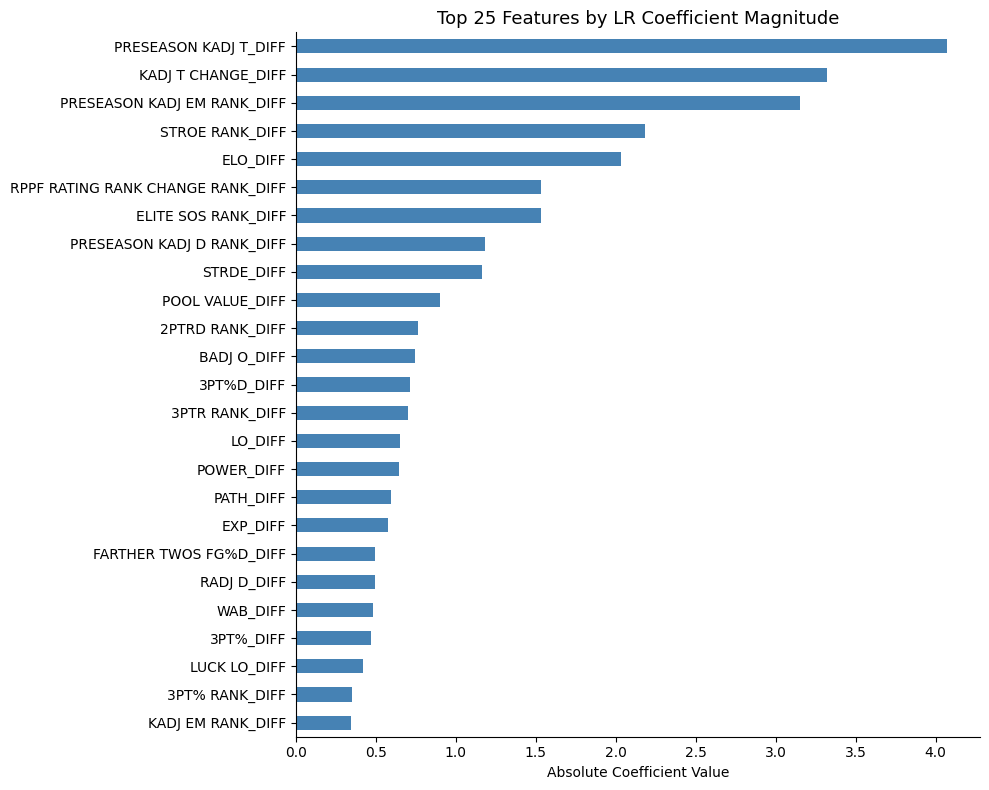


Top 10 features:
PRESEASON KADJ T_DIFF                4.073803
KADJ T CHANGE_DIFF                   3.317917
PRESEASON KADJ EM RANK_DIFF          3.150892
STROE RANK_DIFF                      2.184347
ELO_DIFF                             2.035403
RPPF RATING RANK CHANGE RANK_DIFF    1.534802
ELITE SOS RANK_DIFF                  1.533139
PRESEASON KADJ D RANK_DIFF           1.178991
STRDE_DIFF                           1.162634
POOL VALUE_DIFF                      0.902876


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract the fitted LR model and selector from the pipeline
fitted_selector = best_sgd_pipe.named_steps["selector"]
fitted_sgd       = best_sgd_pipe.named_steps["model"]

# Get the feature names that were selected
support_mask      = fitted_selector.get_support()
# coef_ length == number of selected features, which is reliable
n_selected        = len(fitted_sgd.coef_[0])
# get indices where support_mask is True, capped to feature_cols length
selected_indices  = [i for i, kept in enumerate(support_mask) if kept]
selected_features = [
    feature_cols[i] if i < len(feature_cols) else f"feature_{i}"
    for i in selected_indices
]

# LR coefficients as importance
coefficients = pd.Series(
    np.abs(fitted_sgd.coef_[0]),
    index=selected_features
).sort_values(ascending=True).tail(25)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
coefficients.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 25 Features by LR Coefficient Magnitude", fontsize=13)
ax.set_xlabel("Absolute Coefficient Value")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(coefficients.tail(10).iloc[::-1].to_string())

#### **Function for predicting future games**

In [ ]:
def predict_matchup(team0_name, team1_name, year=2026, round_num=None, verbose=True):
    """
    Predict the winner of a single matchup.
    Returns (winner, prob_team0_wins, prob_team1_wins)
    """
    sources_raw = {
        "_kp":  kenpom_df,       "_ban": bart_away_neut_df,
        "_bn":  bart_neutral_df, "_tr":  teamrankings_df,
        "_res": resumes_df,      "_sh":  shooting_df,
        "_em":  evanmiya_df,     "_rp":  rppf_df,
        "_hc":  heatchk_df,      "_kpp": kenpom_pre_df,
        "_rpp": rppf_pre_df,     "_tra": tr_away_df,
        "_trn": tr_neutral_df,   "_ts":  teamsheet_df,
        "_hct": heatchk_tourney_df,
    }

    row = {}
    for suffix, df in sources_raw.items():
        df_year = df[df["YEAR"] == year]
        t0 = df_year[df_year["TEAM"] == team0_name]
        t1 = df_year[df_year["TEAM"] == team1_name]
        if t0.empty or t1.empty:
            continue
        t0, t1 = t0.iloc[0], t1.iloc[0]
        numeric_cols = df.select_dtypes(include="number").columns.tolist()
        stat_cols = [c for c in numeric_cols if c not in ["YEAR", "TEAM NO", "TEAM ID", "SEED", "ROUND"]]
        for col in stat_cols:
            if col in t0.index and col in t1.index:
                row[col + "_DIFF"] = t0[col] - t1[col]

    # Travel features from locations_df
    loc_year = locations_df[locations_df["YEAR"] == year]
    if "TEAM" in loc_year.columns:
        t0_loc = loc_year[loc_year["TEAM"] == team0_name]
        t1_loc = loc_year[loc_year["TEAM"] == team1_name]
        if not t0_loc.empty and not t1_loc.empty:
            t0_loc, t1_loc = t0_loc.iloc[0], t1_loc.iloc[0]
            row["TRAVEL_DIST_DIFF"]    = t0_loc.get("DISTANCE (MI)", np.nan)            - t1_loc.get("DISTANCE (MI)", np.nan)
            row["TIMEZONE_CROSS_DIFF"] = t0_loc.get("TIME ZONES CROSSED VALUE", np.nan) - t1_loc.get("TIME ZONES CROSSED VALUE", np.nan)

    # Add SEED_DIFF if seeds are available
    kp_year = kenpom_df[kenpom_df["YEAR"] == year]
    t0_kp = kp_year[kp_year["TEAM"] == team0_name]
    t1_kp = kp_year[kp_year["TEAM"] == team1_name]
    if not t0_kp.empty and not t1_kp.empty:
        if "SEED" in t0_kp.columns:
            row["SEED_DIFF"] = t0_kp.iloc[0]["SEED"] - t1_kp.iloc[0]["SEED"]

    # Add CURRENT ROUND if provided
    if round_num is not None:
        row["CURRENT ROUND"] = round_num

    if not row:
        if verbose:
            print(f"Could not find stats for one or both teams. Check team name spelling.")
            print(f"  Available teams for {year}: use list_teams({year}) to check")
        return None, None, None

    # Build input using full training column set — pipeline handles selection internally
    feature_cols = list(X_trainval.columns)
    X_input = pd.DataFrame([{col: row.get(col, np.nan) for col in feature_cols}])[feature_cols]
    prob = best_sgd_pipe.predict_proba(X_input)[0]
    winner = team0_name if prob[1] >= 0.5 else team1_name
    confidence = max(prob[0], prob[1])

    if verbose:
        print(f"{team0_name} vs {team1_name}")
        print(f"  {team0_name} win probability: {prob[1]:.1%}")
        print(f"  {team1_name} win probability: {prob[0]:.1%}")
        print(f"  Predicted winner: {winner} ({confidence:.1%} confidence)")

    return winner, prob[1], prob[0]


def list_teams(year=2026):
    """Print all available team names for a given year."""
    teams = kenpom_df[kenpom_df["YEAR"] == year]["TEAM"].sort_values().tolist()
    print(f"Available teams for {year} ({len(teams)} total):")
    for t in teams:
        print(f"  {t}")


def predict_bracket(bracket, year=2026):
    """
    Predict an entire March Madness bracket.

    bracket: list of 4 regions, each region is a list of 8 first-round matchups.
    Each matchup is a tuple of (team0, team1).

    Example structure:
        bracket = {
            "East":    [(team1, team16), (team8, team9), (team5, team12),
                        (team4, team13), (team6, team11), (team3, team14),
                        (team7, team10), (team2, team15)],
            "West":    [...],
            "South":   [...],
            "Midwest": [...],
        }

    Round numbers: 64=first round, 32=second round, 16=sweet sixteen,
                   8=elite eight, 4=final four, 2=championship
    """
    round_names = {64: "First Round", 32: "Second Round", 16: "Sweet Sixteen",
                    8: "Elite Eight",  4: "Final Four",   2: "Championship"}
    round_nums  = [64, 32, 16, 8, 4, 2]

    print(f"\n{'='*60}")
    print(f"  2026 MARCH MADNESS BRACKET PREDICTION")
    print(f"  Model: SGDClassifier (Test Acc: 82.54%)")
    print(f"{'='*60}")

    region_winners = {}

    for region_name, matchups in bracket.items():
        print(f"\n── {region_name.upper()} REGION ──────────────────────────────")
        current_round = matchups.copy()
        round_idx = 0

        while len(current_round) >= 1:
            round_num = round_nums[round_idx]
            if round_num >= 8:  # print header for all regional rounds including Elite Eight
                print(f"\n  {round_names[round_num]}:")
            next_round = []

            for matchup in current_round:
                team0, team1 = matchup
                winner, p0, p1 = predict_matchup(team0, team1, year=year,
                                                   round_num=round_num, verbose=False)
                if winner is None:
                    print(f"    ⚠ Could not predict {team0} vs {team1} — check team names")
                    winner = team0
                    p0, p1 = 0.5, 0.5

                conf = max(p0, p1) if p0 is not None else 0.5
                loser = team1 if winner == team0 else team0
                print(f"    {winner} def. {loser} ({conf:.0%})")
                next_round.append(winner)

            # Pair up winners for next round
            current_round = list(zip(next_round[::2], next_round[1::2]))
            round_idx += 1

            if len(next_round) == 1:
                region_winners[region_name] = next_round[0]
                print(f"\n  ✓ {region_name} Champion: {next_round[0]}")
                break

    # ── Final Four ────────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  FINAL FOUR")
    print(f"{'='*60}")

    region_list = list(region_winners.items())
    ff_matchups = [
        (region_list[0][1], region_list[2][1]),  # East vs West
        (region_list[1][1], region_list[3][1]),  # South vs Midwest
    ]

    ff_winners = []
    for team0, team1 in ff_matchups:
        winner, p0, p1 = predict_matchup(team0, team1, year=year, round_num=4, verbose=False)
        if winner is None:
            winner = team0
            p0, p1 = 0.5, 0.5
        conf = max(p0, p1)
        loser = team1 if winner == team0 else team0
        print(f"  {winner} def. {loser} ({conf:.0%})")
        ff_winners.append(winner)

    # ── Championship ──────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  NATIONAL CHAMPIONSHIP")
    print(f"{'='*60}")

    winner, p0, p1 = predict_matchup(ff_winners[0], ff_winners[1],
                                      year=year, round_num=2, verbose=False)
    if winner is None:
        winner = ff_winners[0]
    conf = max(p0, p1) if p0 is not None else 0.5
    loser = ff_winners[1] if winner == ff_winners[0] else ff_winners[0]
    print(f"  🏆 CHAMPION: {winner} def. {loser} ({conf:.0%})")

    return winner

In [ ]:
# First Four
_, p0, _ = predict_matchup("Howard", "UMBC", year=2026, round_num=64)
e16 = "Howard" if p0 >= 0.5 else "UMBC"

_, p0, _ = predict_matchup("Lehigh", "Prairie View A&M", year=2026, round_num=64)
s16 = "Lehigh" if p0 >= 0.5 else "Prairie View A&M"

_, p0, _ = predict_matchup("NC State", "Texas", year=2026, round_num=64)
w11 = "NC State" if p0 >= 0.5 else "Texas"

_, p0, _ = predict_matchup("SMU", "Miami (OH)", year=2026, round_num=64)
m11 = "SMU" if p0 >= 0.5 else "Miami (OH)"

# Full bracket with First Four winners slotted in dynamically
bracket = {
    "East": [
        ("Duke", "Siena"),
        ("Ohio St.", "TCU"),
        ("St. John's", "Northern Iowa"),
        ("Kansas", "Cal Baptist"),
        ("Louisville", "South Florida"),
        ("Michigan St.", "North Dakota St."),
        ("UCLA", "UCF"),
        ("UConn", "Furman"),
    ],
    "West": [
        ("Arizona", "Long Island"),
        ("Villanova", "Utah St."),
        ("Wisconsin", "High Point"),
        ("Arkansas", "Hawaii"),
        ("BYU", w11),                  # NC State or Texas
        ("Gonzaga", "Kennesaw St."),
        ("Miami (FL)", "Missouri"),
        ("Purdue", "Queens (N.C.)"),
    ],
    "South": [
        ("Florida", s16),              # Lehigh or Prairie View A&M
        ("Clemson", "Iowa"),
        ("Vanderbilt", "McNeese"),
        ("Nebraska", "Troy"),
        ("North Carolina", "VCU"),
        ("Illinois", "Penn"),
        ("Saint Mary's", "Texas A&M"),
        ("Houston", "Idaho"),
    ],
    "Midwest": [
        ("Michigan", e16),             # Howard or UMBC
        ("Georgia", "Saint Louis"),
        ("Texas Tech", "Akron"),
        ("Alabama", "Hofstra"),
        ("Tennessee", m11),            # SMU or Miami (OH)
        ("Virginia", "Wright St."),
        ("Kentucky", "Santa Clara"),
        ("Iowa St.", "Tennessee St."),
    ],
}

champion = predict_bracket(bracket, year=2026)

Howard vs UMBC
  Howard win probability: 42.4%
  UMBC win probability: 57.6%
  Predicted winner: UMBC (57.6% confidence)
Lehigh vs Prairie View A&M
  Lehigh win probability: 39.5%
  Prairie View A&M win probability: 60.5%
  Predicted winner: Prairie View A&M (60.5% confidence)
NC State vs Texas
  NC State win probability: 51.8%
  Texas win probability: 48.2%
  Predicted winner: NC State (51.8% confidence)
SMU vs Miami (OH)
  SMU win probability: 51.8%
  Miami (OH) win probability: 48.2%
  Predicted winner: SMU (51.8% confidence)

  2026 MARCH MADNESS BRACKET PREDICTION
  Model: SGDClassifier (Test Acc: 82.54%)

── EAST REGION ──────────────────────────────

  First Round:
    Duke def. Siena (83%)
    TCU def. Ohio St. (50%)
    St. John's def. Northern Iowa (54%)
    Kansas def. Cal Baptist (92%)
    Louisville def. South Florida (64%)
    Michigan St. def. North Dakota St. (71%)
    UCLA def. UCF (76%)
    UConn def. Furman (52%)

  Second Round:
    Duke def. TCU (73%)
    St. John'

In [ ]:
# Model graveyard

# # ── LightGBM ────────────────────────────────────────────────────────────────
# def lgbm_objective(trial):
#     max_features = trial.suggest_int("max_features", 50, 100)
#     params = dict(
#         n_estimators      = trial.suggest_int("n_estimators", 200, 800),
#         max_depth         = trial.suggest_int("max_depth", 3, 8),
#         learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         num_leaves        = trial.suggest_int("num_leaves", 20, 150),
#         subsample         = trial.suggest_float("subsample", 0.6, 1.0),
#         colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         min_child_samples = trial.suggest_int("min_child_samples", 5, 50),
#         reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
#         reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
#         random_state=27, n_jobs=-1, verbose=-1,
#     )
#     pipe = Pipeline([
#         ("imputer",  SimpleImputer(strategy="median")),
#         ("scaler",   StandardScaler()),
#         ("selector", SelectFromModel(
#             XGBClassifier(n_estimators=100, max_depth=3, random_state=27, n_jobs=-1),
#             max_features=max_features
#         )),
#         ("model", LGBMClassifier(**params)),
#     ])
#     scores = cross_val_score(pipe, X_trainval_raw, y_trainval,
#                              cv=tscv, scoring="accuracy")
#     return scores.mean()

# print("Tuning LightGBM (100 trials)...")
# lgbm_study = optuna.create_study(direction="maximize", sampler=sampler)
# lgbm_study.optimize(lgbm_objective, n_trials=100, show_progress_bar=True)

# best_lgbm_pipe = Pipeline([
#     ("imputer",  SimpleImputer(strategy="median")),
#     ("scaler",   StandardScaler()),
#     ("selector", SelectFromModel(
#         XGBClassifier(n_estimators=100, max_depth=3, random_state=27, n_jobs=-1),
#         max_features=lgbm_study.best_params["max_features"]
#     )),
#     ("model", LGBMClassifier(
#         **{k: v for k, v in lgbm_study.best_params.items() if k != "max_features"},
#         random_state=27, n_jobs=-1, verbose=-1
#     )),
# ])
# best_lgbm_pipe.fit(X_trainval_raw, y_trainval)
# results.append({
#     "Model":        "LightGBM (tuned)",
#     "CV Acc":       lgbm_study.best_value,
#     "Test Acc":     accuracy_score(y_test, best_lgbm_pipe.predict(X_test_raw)),
#     "Test LogLoss": log_loss(y_test, best_lgbm_pipe.predict_proba(X_test_raw)),
# })
# print(f"  Best CV acc: {lgbm_study.best_value:.4f}  |  Test acc: {results[-1]['Test Acc']:.4f}")
# print(f"  Best max_features: {lgbm_study.best_params['max_features']}")

# # ── Random Forest ───────────────────────────────────────────────────────────
# def rf_objective(trial):
#     max_features = trial.suggest_int("max_features", 50, 100)
#     params = dict(
#         n_estimators      = trial.suggest_int("n_estimators", 100, 800),
#         max_depth         = trial.suggest_int("max_depth", 3, 15),
#         min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
#         min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10),
#         max_features      = trial.suggest_float("max_features_rf", 0.3, 1.0),
#         random_state=27, n_jobs=-1,
#     )
#     pipe = Pipeline([
#         ("imputer",  SimpleImputer(strategy="median")),
#         ("scaler",   StandardScaler()),
#         ("selector", SelectFromModel(
#             XGBClassifier(n_estimators=100, max_depth=3, random_state=27, n_jobs=-1),
#             max_features=max_features
#         )),
#         ("model", RandomForestClassifier(**params)),
#     ])
#     scores = cross_val_score(pipe, X_trainval_raw, y_trainval,
#                              cv=tscv, scoring="accuracy")
#     return scores.mean()

# print("\nTuning Random Forest (75 trials)...")
# rf_study = optuna.create_study(direction="maximize", sampler=sampler)
# rf_study.optimize(rf_objective, n_trials=75, show_progress_bar=True)

# best_rf_pipe = Pipeline([
#     ("imputer",  SimpleImputer(strategy="median")),
#     ("scaler",   StandardScaler()),
#     ("selector", SelectFromModel(
#         XGBClassifier(n_estimators=100, max_depth=3, random_state=27, n_jobs=-1),
#         max_features=rf_study.best_params["max_features"]
#     )),
#     ("model", RandomForestClassifier(
#         **{k: v for k, v in rf_study.best_params.items() if k not in ["max_features", "max_features_rf"]},
#         max_features=rf_study.best_params["max_features_rf"],
#         random_state=27, n_jobs=-1
#     )),
# ])
# best_rf_pipe.fit(X_trainval_raw, y_trainval)
# results.append({
#     "Model":        "Random Forest (tuned)",
#     "CV Acc":       rf_study.best_value,
#     "Test Acc":     accuracy_score(y_test, best_rf_pipe.predict(X_test_raw)),
#     "Test LogLoss": log_loss(y_test, best_rf_pipe.predict_proba(X_test_raw)),
# })
# print(f"  Best CV acc: {rf_study.best_value:.4f}  |  Test acc: {results[-1]['Test Acc']:.4f}")
# print(f"  Best max_features: {rf_study.best_params['max_features']}")

# # ── Passive Aggressive Classifier ─────────────────────────────────────────────
# def pa_objective(trial):
#     params = dict(
#         C = trial.suggest_float("C", 1e-4, 10.0, log=True),
#     )
#     base      = PassiveAggressiveClassifier(**params, max_iter=2000, random_state=seed)
#     calibrated = CalibratedClassifierCV(base, cv=3, method="isotonic")
#     pipe = Pipeline([
#         ("imputer",  SimpleImputer(strategy="median")),
#         ("scaler",   StandardScaler()),
#         ("selector", make_selector()),
#         ("model",    calibrated),
#     ])
#     return cross_val_score(pipe, X_trainval_raw, y_trainval, cv=tscv, scoring="accuracy").mean()

# print("\nTuning Passive Aggressive Classifier (50 trials)...")
# pa_study = optuna.create_study(
#     direction="maximize",
#     sampler=optuna.samplers.TPESampler(seed=seed)
# )
# pa_study.optimize(pa_objective, n_trials=50, show_progress_bar=True)

# best_pa_base = PassiveAggressiveClassifier(
#     C=pa_study.best_params["C"], max_iter=2000, random_state=seed
# )
# best_pa_pipe = Pipeline([
#     ("imputer",  SimpleImputer(strategy="median")),
#     ("scaler",   StandardScaler()),
#     ("selector", make_selector()),
#     ("model",    CalibratedClassifierCV(best_pa_base, cv=3, method="isotonic")),
# ])
# best_pa_pipe.fit(X_trainval_raw, y_trainval)
# results.append({
#     "Model":        "Passive Aggressive",
#     "CV Acc":       pa_study.best_value,
#     "Test Acc":     accuracy_score(y_test, best_pa_pipe.predict(X_test_raw)),
#     "Test LogLoss": log_loss(y_test, best_pa_pipe.predict_proba(X_test_raw)),
# })
# print(f"  Best CV acc: {pa_study.best_value:.4f}  |  Test acc: {results[-1]['Test Acc']:.4f}")
# print(f"  Best C: {pa_study.best_params['C']:.6f}")
